In [ ]:
# Using "bifurcationkit_tutorial.ipynb as a starting point for this code
# I made bifurcationkit_tutorial.ipynb to show folks in my group how to use the package earlier this semester
using Pkg
Pkg.activate("/Users/alia/Desktop/envs/ants") # activate environment with the appropriate packages

# import BifurcationKit and other useful packages
using BifurcationKit
using Plots
using LaTeXStrings
using CSV
using DataFrames
using Plots.PlotMeasures

  Activating project at `~/Desktop/envs/ants`


\begin{align}
    \dot p = \bar\beta(1+x)(1-p)p - \delta p\\
    \tau_x\dot x = -x + \tanh\left((k_p p + k_x x^2 + u_0)x\right)
\end{align}

Defining the dynamics:

In [ ]:
function NOD_SIS(y,par)
    (beta,delta,kp,kx,u0,tau) = par
    p = y[1]
    x = y[2]
    pdot = beta*(1+x)*(1-p)*p - delta*p
    xdot = (-x +tanh((kp*p + kx*x*x + u0)*x))/tau
    [
        pdot
        xdot
    ]
end

# set parameters and initial condition
par = (beta = 0.36,delta = 0.3,kp = 0.7,kx = 0.3,u0 = 0.7,tau = 1)
y0 = [0.5,0.0]

# define the problem
prob = BifurcationProblem(NOD_SIS,
    y0,
    par,
    (@optic _.beta),
    record_from_solution = (x, p; k...) -> (p = x[1],x = x[2]))

┌─ Bifurcation problem with uType Vector{Float64}
├─ Inplace: false
├─ Dimension: 2
├─ Symmetric: false
└─ Parameter: beta

In [ ]:
#choose options for continuation

opts_br = ContinuationPar(
    p_min = 0.0, p_max = 1.0, # parameter range to investiage
    ds = 5e-4, # typical ds value
    dsmax = 5e-3,
    dsmin = 1e-4,
    detect_bifurcation = 3,
    n_inversion = 6
)


#run continuation
diagram = bifurcationdiagram(
    prob,
    PALC(), #use pseudo-arclength continuation
    2, # recursion level (sufficient for the problem at hand)
    opts_br, # give options
    bothside = true, # compute both directions of branches
    tol_stability = 1e-8
)

[Bifurcation diagram]
 ┌─ From 0-th bifurcation point.
 ├─ Children number: 4
 └─ Root (recursion level 1)
      ┌─ Curve type: EquilibriumCont
      ├─ Number of points: 516
      ├─ Type of vectors: Vector{Float64}
      ├─ Parameter beta starts at 0.06341371713396848, ends at 1.0
      ├─ Algo: PALC [Secant]
      └─ Special points:

- #  1, endpoint at beta ≈ +0.06327998,                                                                     step =  -1
- #  2,       bp at beta ≈ +0.29999993 ∈ (+0.29999993, +0.30000001), |δp|=8e-08, [converged], δ = (-1,  0), step = 376
- #  3,       bp at beta ≈ +0.52500424 ∈ (+0.52499877, +0.52500424), |δp|=5e-06, [converged], δ = ( 1,  0), step = 441
- #  4, endpoint at beta ≈ +1.00000000,                                                                     step = 515


In [ ]:
# View info about third bifurcation point not on the initial branch
diagram.child[3]

[Bifurcation diagram]
 ┌─ From 3-th bifurcation point.
 ├─ Children number: 0
 └─ Root (recursion level 2)
      ┌─ Curve type: EquilibriumCont from Transcritical bifurcation point.
      ├─ Number of points: 268
      ├─ Type of vectors: Vector{Float64}
      ├─ Parameter beta starts at 1.0, ends at 1.0
      ├─ Algo: PALC [Secant]
      └─ Special points:

- #  1, endpoint at beta ≈ +1.00000000,                                                                     step =   0
- #  2,       bp at beta ≈ +0.36974549 ∈ (+0.36974549, +0.36974549), |δp|=2e-10, [converged], δ = ( 1,  0), step = 112
- #  3,       bp at beta ≈ +0.52477321 ∈ (+0.52477321, +0.52501213), |δp|=2e-04, [    guess], δ = (-1,  0), step = 176
- #  4,       bp at beta ≈ +0.52514665 ∈ (+0.52500424, +0.52514665), |δp|=1e-04, [    guess], δ = (-1,  0), step = 180
- #  5, endpoint at beta ≈ +1.00000000,                                                                     step = 267


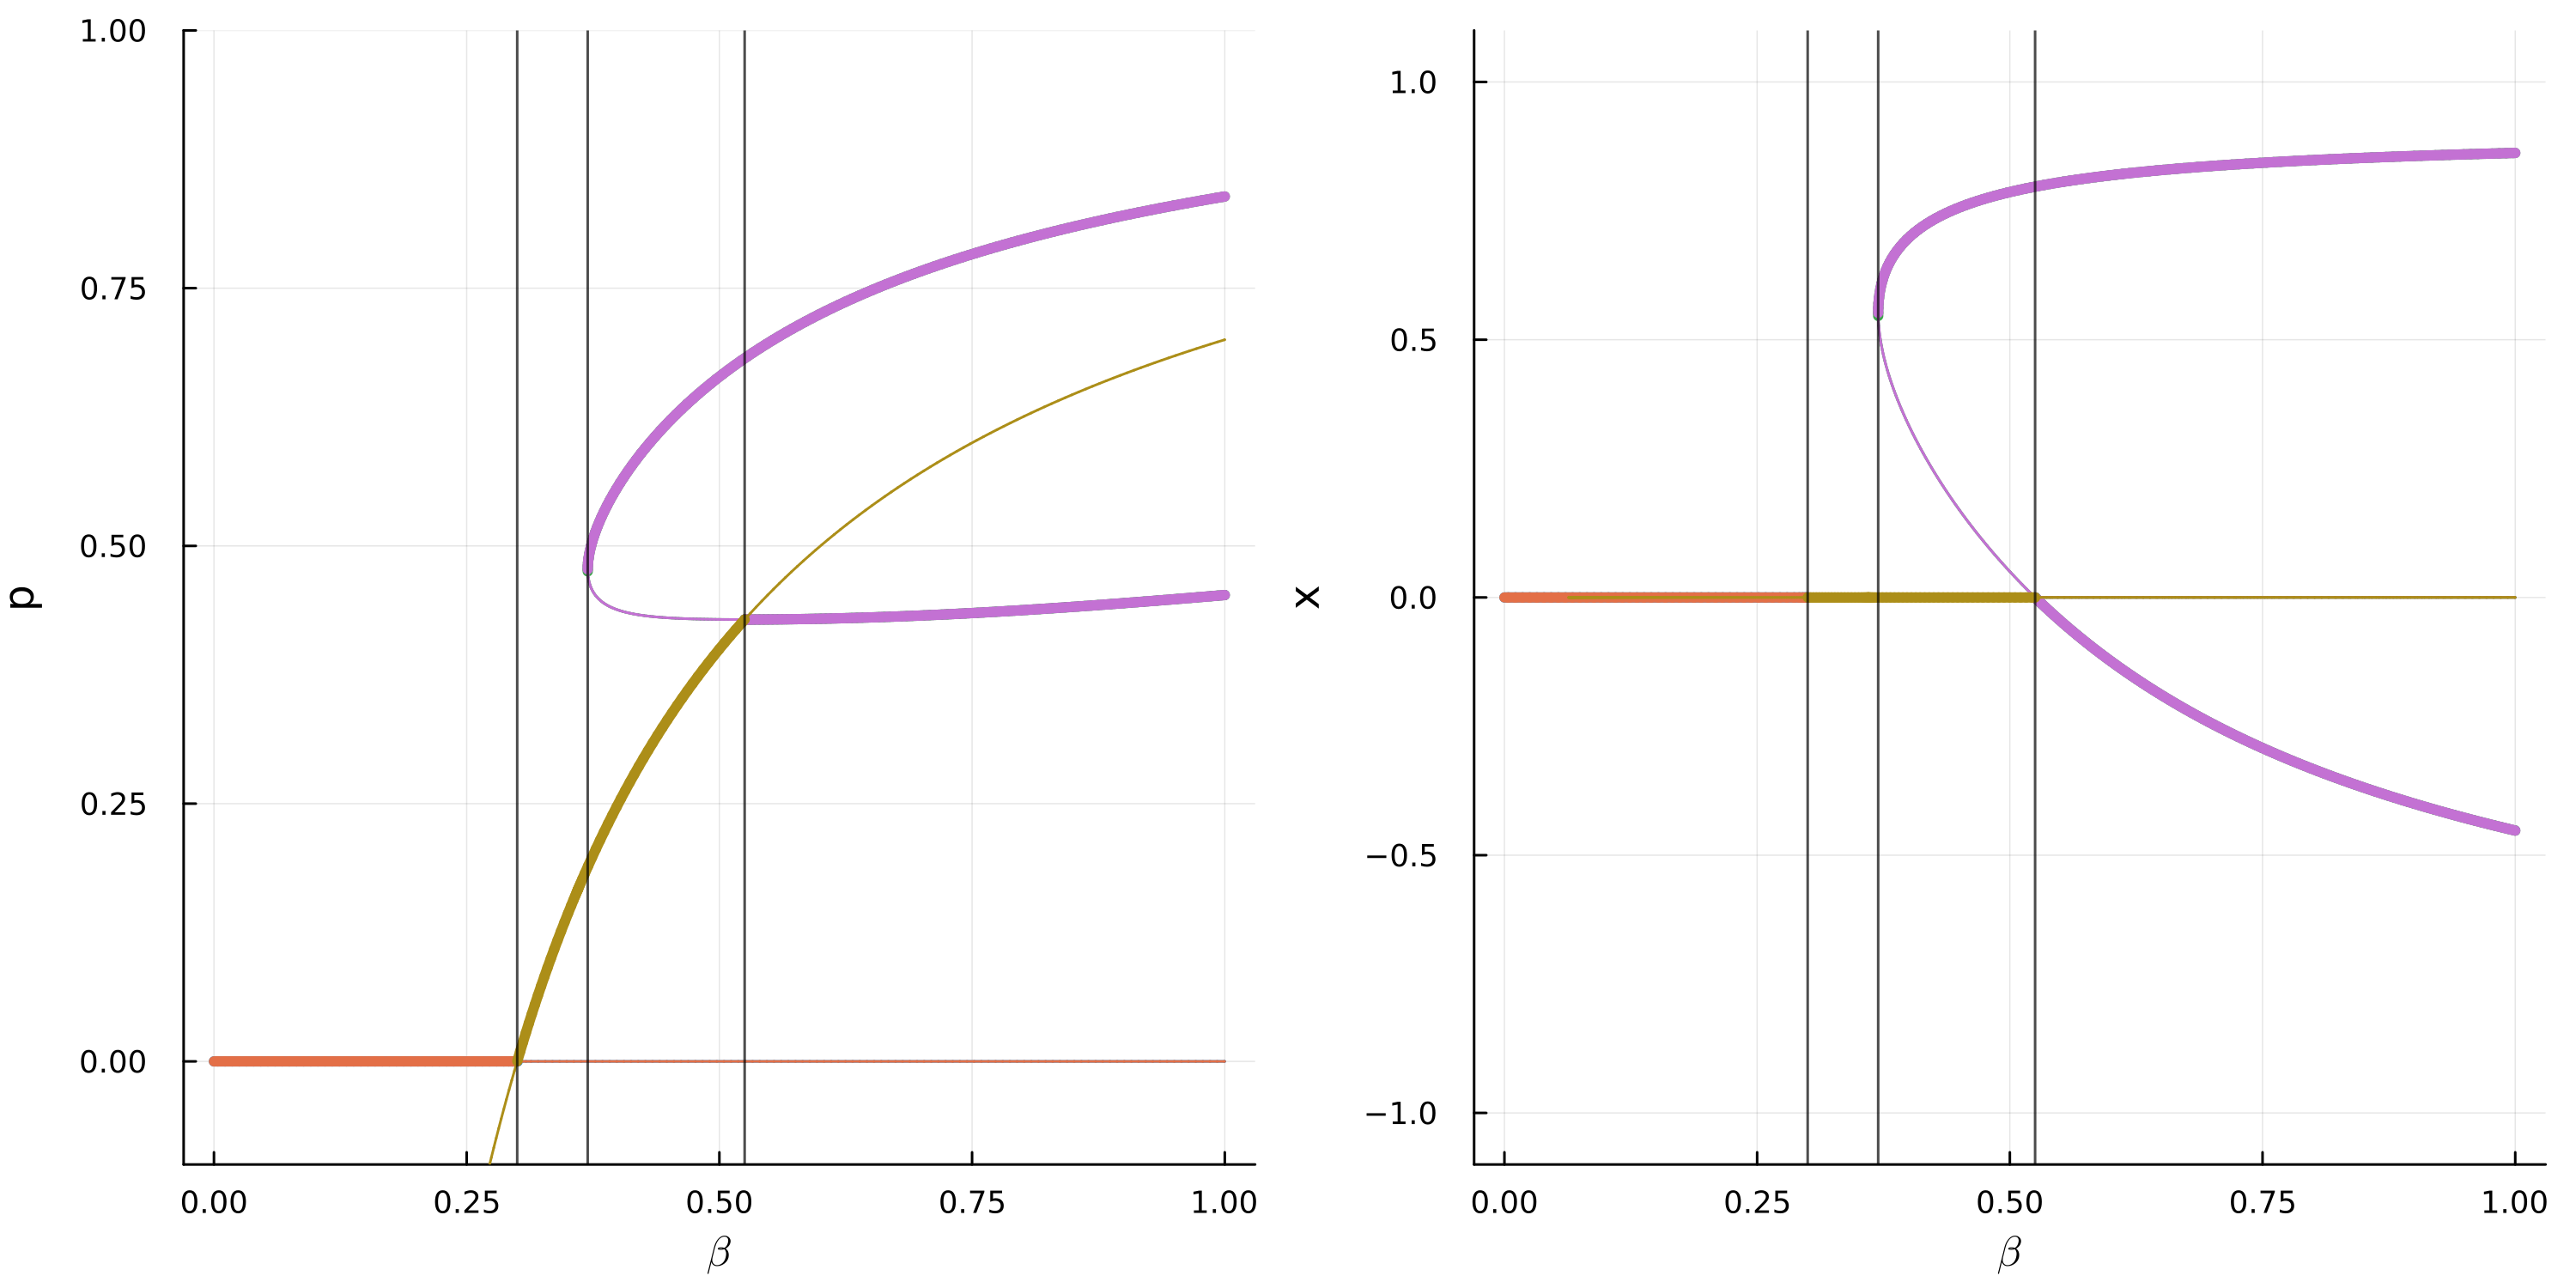

In [ ]:
# plot results

plt = plot(plot(diagram,vars = (:param,:p),ylim = [-0.1,1],xlabel = L"\beta",plotspecialpoints = false,linewidthstable = 4,linewidthunstable = 1,leg = false),
    plot(diagram,vars = (:param,:x),ylim = [-1.1,1.1],xlabel = L"\beta",plotspecialpoints = false, linewidthstable = 4,linewidthunstable = 1,leg = false),
    layout = (1,2),size = (1000,500),dpi = 300,left_margin = 3mm,bottom_margin = 3mm)

# plot vertical lines at bifurcation points. Points copied from the two previous cells
vline!(plt[1], [0.3,0.52500424,0.36974549],color = "black",alpha = 0.7)
vline!(plt[2], [0.3,0.52500424,0.36974549],color = "black",alpha = 0.7)